In [60]:
import pandas as pd
import numpy as np
import re
import nltk

In [61]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [62]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [63]:
df = pd.read_csv("sentiment.csv")

In [64]:
print(df.head())

                                 review sentiment
0    This movie was absolutely amazing!  positive
1         I loved the acting and story.  positive
2    The movie was boring and too long.  negative
3       Terrible acting and weak story.  negative
4  The movie was okay, nothing special.   neutral


In [65]:
print(df.shape)
print(df.columns)
print(df["sentiment"].value_counts())

(45, 2)
Index(['review', 'sentiment'], dtype='str')
sentiment
positive    18
negative    18
neutral      9
Name: count, dtype: int64


In [66]:
print(df.isnull().sum())   # missing values

review       0
sentiment    0
dtype: int64


In [67]:
X = df["review"]
y = df["sentiment"]

In [68]:
print(X.head())
print(y.head())

0      This movie was absolutely amazing!
1           I loved the acting and story.
2      The movie was boring and too long.
3         Terrible acting and weak story.
4    The movie was okay, nothing special.
Name: review, dtype: str
0    positive
1    positive
2    negative
3    negative
4     neutral
Name: sentiment, dtype: str


In [69]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [70]:
def preprocess_text(text):  #preprocessing

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    # Join words
    return " ".join(words)

In [71]:
df["clean_review"] = df["review"].apply(preprocess_text)

In [72]:
print(df[["review", "clean_review"]].head())

                                 review                clean_review
0    This movie was absolutely amazing!    movie absolutely amazing
1         I loved the acting and story.          loved acting story
2    The movie was boring and too long.           movie boring long
3       Terrible acting and weak story.  terrible acting weak story
4  The movie was okay, nothing special.  movie okay nothing special


In [73]:
["movie", "was", "amazing"]

['movie', 'was', 'amazing']

In [74]:
text = "This movie was amazing"

tokens = text.lower().split()

print(tokens)

['this', 'movie', 'was', 'amazing']


In [75]:
text = "This movie was amazing"

tokens = text.lower().split()

filtered_words = [
    word for word in tokens
    if word not in stop_words
]

print(filtered_words)

['movie', 'amazing']


In [76]:
words = ["playing", "played", "plays", "better"]

for word in words:
    print(
        word,
        "→",
        lemmatizer.lemmatize(word)
    )

playing → playing
played → played
plays → play
better → better


In [77]:
X = df["clean_review"]
y = df["sentiment"]

In [78]:
y = y.map({
    "positive": 1,
    "negative": 0
})
print(y.head())

0    1.0
1    1.0
2    0.0
3    0.0
4    NaN
Name: sentiment, dtype: float64


In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ValueError: Input y contains NaN.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
bow = CountVectorizer()
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
print(X_train_bow.shape)
print(X_test_bow.shape)

(4, 10)
(2, 10)


In [ ]:
print(bow.vocabulary_)
print(bow.get_feature_names_out())

{'movie': 8, 'boring': 2, 'long': 7, 'excellent': 4, 'acting': 0, 'great': 5, 'story': 9, 'hated': 6, 'amazing': 1, 'entertaining': 3}
['acting' 'amazing' 'boring' 'entertaining' 'excellent' 'great' 'hated'
 'long' 'movie' 'story']


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(
    X_train_bow,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
y_pred = model.predict(X_test_bow)
print(y_pred)

[0 1]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.0


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       1.0
    Positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[0 1]
 [1 0]]


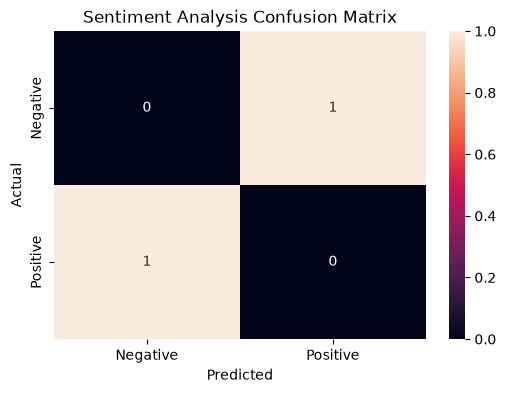

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Analysis Confusion Matrix")

plt.show()

In [ ]:
def predict_sentiment(review):

    # preprocessing
    cleaned = preprocess_text(review)

    # BoW
    vector = bow.transform([cleaned])

    # prediction
    prediction = model.predict(vector)[0]

    if prediction == 1:
        return "Positive 😊"
    else:
        return "Negative 😞"

In [ ]:
review = "This movie was amazing and I really loved it"

print(predict_sentiment(review))

Positive 😊


In [ ]:
review = "This movie was extremely boring and terrible"

print(predict_sentiment(review))

Negative 😞


In [ ]:
import pickle

# Save ML model
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save BoW vectorizer
with open("bow_vectorizer.pkl", "wb") as f:
    pickle.dump(bow, f)